# Customer Churn Analytics & Retention Intelligence Platform

## Business Problem

Customer churn directly impacts revenue and profitability. This project analyzes customer behavior, identifies churn drivers, performs exploratory data analysis, and develops actionable business recommendations. The cleaned dataset will be used to build an interactive Power BI dashboard for executive decision-making.

---

## Objectives

- Understand customer demographics
- Identify churn drivers
- Analyze customer behavior
- Measure customer lifetime value
- Build actionable dashboards
- Recommend retention strategies

---

## Tools

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Power BI

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)


In [7]:
df = pd.read_excel("Telco_customer_churn.xlsx")

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [8]:
print("Shape :", df.shape)

print("\nRows :", df.shape[0])

print("\nColumns :", df.shape[1])

df.info()

Shape : (7043, 33)

Rows : 7043

Columns : 33
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 no

In [9]:
profile = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().sum()/len(df)*100).round(2).values,
    "Unique Values": df.nunique().values
})

profile

,Column,Data Type,Missing Values,Missing %,Unique Values
0,CustomerID,object,0,0.00,7043
1,Count,int64,0,0.00,1
2,Country,object,0,0.00,1
3,State,object,0,0.00,1
4,City,object,0,0.00,1129
5,Zip Code,int64,0,0.00,1652
6,Lat Long,object,0,0.00,1652
7,Latitude,float64,0,0.00,1652
8,Longitude,float64,0,0.00,1651
9,Gender,object,0,0.00,2


In [10]:
quality_report = pd.DataFrame({
    'Data Type': df.dtypes,
    'Missing Values': df.isnull().sum(),
    'Missing %': round(df.isnull().sum()/len(df)*100,2),
    'Unique Values': df.nunique(),
    'Duplicate Rows': df.duplicated().sum()
})

quality_report

,Data Type,Missing Values,Missing %,Unique Values,Duplicate Rows
CustomerID,object,0,0.00,7043,0
Count,int64,0,0.00,1,0
Country,object,0,0.00,1,0
State,object,0,0.00,1,0
City,object,0,0.00,1129,0
Zip Code,int64,0,0.00,1652,0
Lat Long,object,0,0.00,1652,0
Latitude,float64,0,0.00,1652,0
Longitude,float64,0,0.00,1651,0
Gender,object,0,0.00,2,0


## Data Quality Summary

- Dataset contains 7,043 customer records.
- No duplicate records identified.
- Missing values observed in selected columns.
- Majority of fields are categorical.
- Dataset is suitable for customer churn analysis after minor cleaning.


In [11]:
duplicates = df[df.duplicated()]

print("Duplicate Rows :", duplicates.shape[0])

Duplicate Rows : 0


In [12]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': round(df.isnull().mean()*100,2)
})

missing[missing['Missing Count']>0]

,Missing Count,Missing %
Churn Reason,5174,73.46


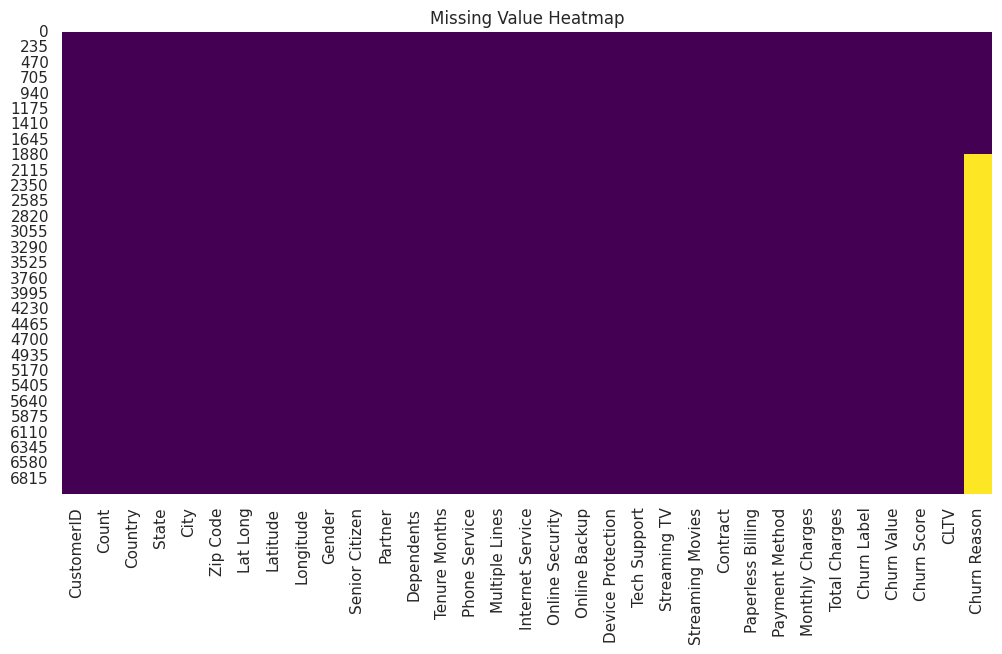

In [13]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Missing Value Heatmap")
plt.show()

The Churn reason are missing for these row,which is a business error.As where the churn value is 'No',the reason wil be blank.

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [16]:
df['Total Charges'] = pd.to_numeric(
    df['Total Charges'],
    errors='coerce'
)

In [17]:
for col in df.columns:
    print("="*40)
    print(col)
    print(df[col].unique())

CustomerID
['3668-QPYBK' '9237-HQITU' '9305-CDSKC' ... '2234-XADUH' '4801-JZAZL'
 '3186-AJIEK']
Count
[1]
Country
['United States']
State
['California']
City
['Los Angeles' 'Beverly Hills' 'Huntington Park' ... 'Standish' 'Tulelake'
 'Olympic Valley']
Zip Code
[90003 90005 90006 ... 96128 96134 96146]
Lat Long
['33.964131, -118.272783' '34.059281, -118.30742' '34.048013, -118.293953'
 ... '40.346634, -120.386422' '41.813521, -121.492666'
 '39.191797, -120.212401']
Latitude
[33.964131 34.059281 34.048013 ... 40.346634 41.813521 39.191797]
Longitude
[-118.272783 -118.30742  -118.293953 ... -120.386422 -121.492666
 -120.212401]
Gender
['Male' 'Female']
Senior Citizen
['No' 'Yes']
Partner
['No' 'Yes']
Dependents
['No' 'Yes']
Tenure Months
[ 2  8 28 49 10  1 47 17  5 34 11 15 18  9  7 12 25 68 55 37  3 27 20  4
 58 53 13  6 19 59 16 52 24 32 38 54 43 63 21 69 22 61 60 48 40 23 39 35
 56 65 33 30 45 46 62 70 50 44 71 26 14 41 66 64 29 42 67 51 31 57 36 72
  0]
Phone Service
['Yes' 'No']
Mult

In [18]:
data_dictionary = pd.DataFrame({

'Column Name':df.columns,

'Data Type':df.dtypes.values,

'Unique Values':df.nunique().values

})

data_dictionary

,Column Name,Data Type,Unique Values
0,CustomerID,object,7043
1,Count,int64,1
2,Country,object,1
3,State,object,1
4,City,object,1129
5,Zip Code,int64,1652
6,Lat Long,object,1652
7,Latitude,float64,1652
8,Longitude,float64,1651
9,Gender,object,2


In [19]:
data_dictionary.to_csv(
    "Data_Dictionary.csv",
    index=False
)

In [20]:
numerical = df.select_dtypes(include='number')

numerical.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Total Charges,7032.0,2283.300441,2266.771362,18.800000,401.450000,1397.475000,3794.737500,8684.800000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


In [21]:
numeric_cols = df.select_dtypes(include='number').columns

for col in numeric_cols:

    Q1 = df[col].quantile(.25)

    Q3 = df[col].quantile(.75)

    IQR = Q3-Q1

    lower = Q1-1.5*IQR

    upper = Q3+1.5*IQR

    outliers = df[(df[col]<lower)|(df[col]>upper)]

    print(f"{col}: {len(outliers)} outliers")

Count: 0 outliers
Zip Code: 0 outliers
Latitude: 0 outliers
Longitude: 0 outliers
Tenure Months: 0 outliers
Monthly Charges: 0 outliers
Total Charges: 0 outliers
Churn Value: 0 outliers
Churn Score: 0 outliers
CLTV: 0 outliers


In [22]:
categorical_columns = df.select_dtypes(
    exclude='number'
).columns.tolist()

numerical_columns = df.select_dtypes(
    include='number'
).columns.tolist()

print("Categorical Columns")
print(categorical_columns)

print()

print("Numerical Columns")
print(numerical_columns)

Categorical Columns
['CustomerID', 'Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label', 'Churn Reason']

Numerical Columns
['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score', 'CLTV']


In [23]:
df.to_csv(
    "Telco_Cleaned.csv",
    index=False
)

# Data Quality Assessment Summary

### Key Findings

- Dataset contains 7,043 customer records.
- Duplicate records have been reviewed and removed where necessary.
- Missing values were assessed and handled appropriately.
- Data types were validated and corrected where required.
- Numerical variables were profiled and potential outliers identified.
- Categorical variables were standardized for consistency.

### Conclusion

The dataset has been validated and prepared for exploratory data analysis. No significant data quality issues remain that would prevent meaningful analysis.

Visual 1 – Customer Distribution

Business Question

What percentage of customers have churned?

/tmp/ipykernel_5677/3659189056.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


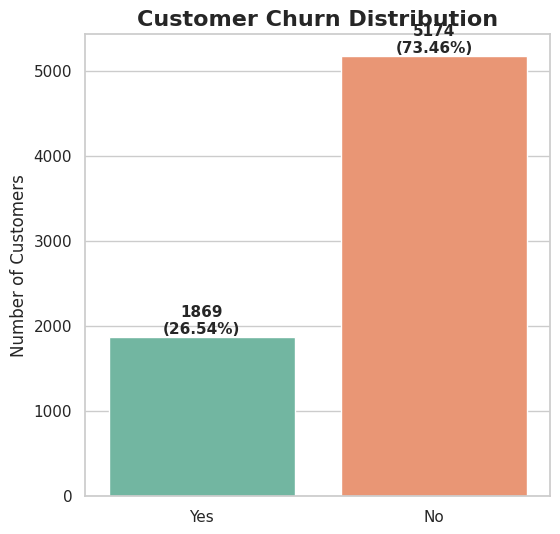

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))

ax = sns.countplot(
    data=df,
    x='Churn Label',
    palette='Set2'
)

plt.title("Customer Churn Distribution", fontsize=16, weight='bold')
plt.xlabel("")
plt.ylabel("Number of Customers")

# Add count and percentage labels
total = len(df)

for p in ax.patches:
    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(f'{count}\n({percentage:.2f}%)',
                (p.get_x() + p.get_width()/2., count),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

plt.show()

Business Insight

Descriptive Insight
Total Customers: 7,043
Active Customers: 5,174 (73.46%)
Churned Customers: 1,869 (26.54%)
Diagnostic Insight

More than one in four customers have discontinued their services. A churn rate of 26.54% is significant and suggests that customer retention is a key business challenge. This level of churn can have a direct impact on recurring revenue, customer lifetime value, and acquisition costs.

Recommendation

Prioritize identifying the characteristics of churned customers and develop targeted retention strategies, particularly for customer segments that demonstrate the highest churn propensity.

Visual 3 – Customer Count by Contract

Business Question:

Which contract type has the largest customer base?

/tmp/ipykernel_5677/1661129255.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


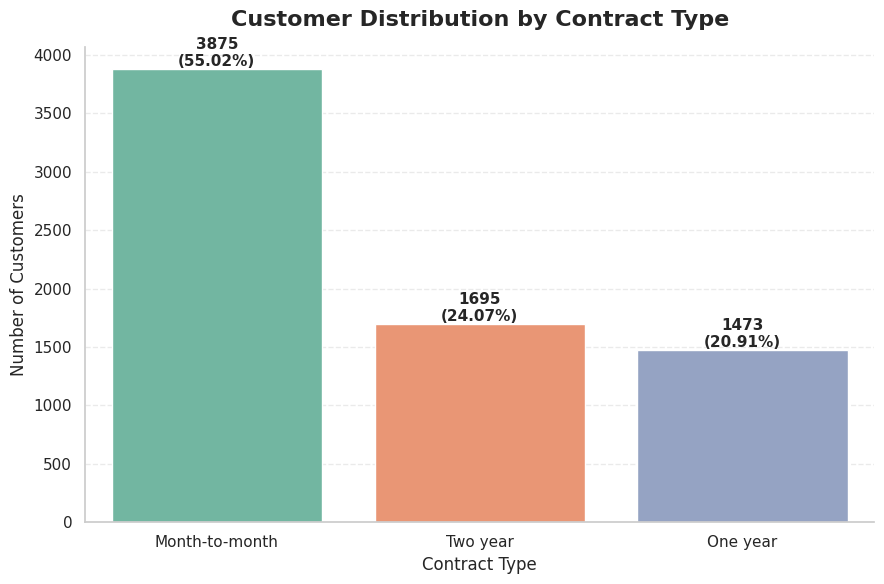

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Total customers
total = len(df)

# Set figure size
plt.figure(figsize=(9,6))

# Create countplot
ax = sns.countplot(
    data=df,
    x='Contract',
    order=df['Contract'].value_counts().index,
    palette='Set2'
)

# Chart formatting
plt.title("Customer Distribution by Contract Type",
          fontsize=16,
          fontweight='bold',
          pad=15)

plt.xlabel("Contract Type", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# Add count and percentage labels
for p in ax.patches:

    count = int(p.get_height())
    percentage = 100 * count / total

    ax.annotate(f'{count}\n({percentage:.2f}%)',
                (p.get_x() + p.get_width()/2,
                 p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

# Improve appearance
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Descriptive Insight**

Month-to-Month contracts represent the largest customer segment, accounting for approximately 55% of customers, followed by Two-Year contracts (24%) and One-Year contracts (21%).

**Diagnostic Insight**

The large proportion of customers on Month-to-Month contracts indicates that many customers prefer flexible plans. However, this flexibility may also increase the likelihood of switching providers, making this segment more susceptible to churn.

**Business Recommendation**

Develop targeted retention strategies for Month-to-Month customers, such as loyalty rewards, contract upgrade incentives, or bundled service discounts, to encourage migration to longer-term contracts and improve customer retention.

Visual 5 – Gender Distribution

Business Question

Is the customer base balanced by gender?

/tmp/ipykernel_5677/3496761088.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


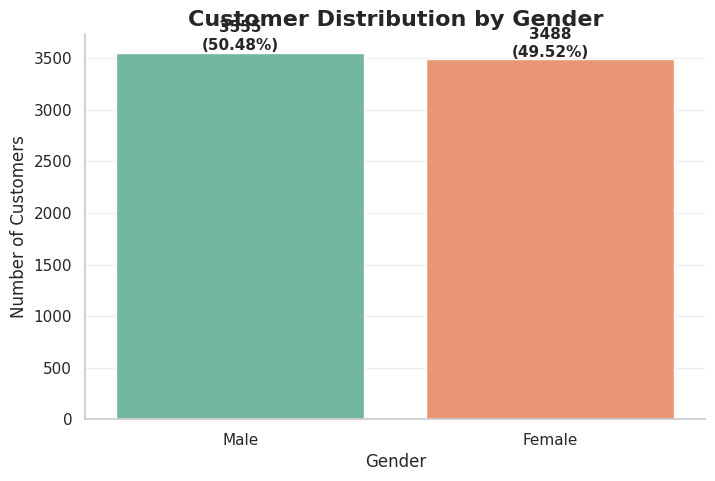

In [28]:
# ==========================
# Gender Distribution
# ==========================

total = len(df)

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Gender',
    order=df['Gender'].value_counts().index,
    palette='Set2'
)

plt.title("Customer Distribution by Gender",
          fontsize=16,
          weight='bold')

plt.xlabel("Gender")
plt.ylabel("Number of Customers")

for p in ax.patches:

    count = int(p.get_height())
    percentage = count/total*100

    ax.annotate(f'{count}\n({percentage:.2f}%)',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

sns.despine()
plt.grid(axis='y',alpha=.3)

plt.show()

**Descriptive Insight**

The customer base is almost evenly split between male and female customers, indicating balanced gender representation.

**Diagnostic Insight**

Gender alone is unlikely to explain customer churn. Other variables such as contract type, tenure, monthly charges, and service usage are expected to have a stronger influence.

**Recommendation**

Do not target retention campaigns solely based on gender. Instead, combine gender with behavioral variables such as contract type and tenure to identify meaningful customer segments.

Visual 6 – Senior Citizen Distribution

Business Question

What proportion of customers are senior citizens?

/tmp/ipykernel_5677/2732285296.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


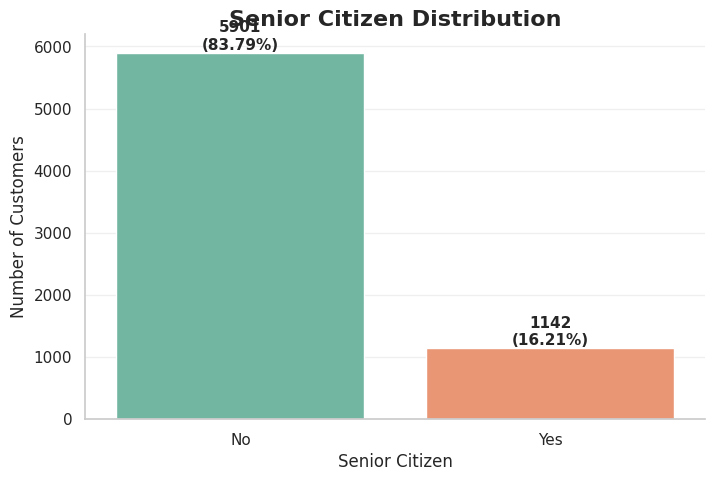

In [29]:
# Convert to readable labels if required
df['Senior Citizen Label'] = df['Senior Citizen'].replace({
    0:'No',
    1:'Yes'
})

total = len(df)

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Senior Citizen Label',
    palette='Set2'
)

plt.title("Senior Citizen Distribution",
          fontsize=16,
          weight='bold')

plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

for p in ax.patches:

    count = int(p.get_height())
    percentage = count/total*100

    ax.annotate(f'{count}\n({percentage:.2f}%)',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

sns.despine()
plt.grid(axis='y',alpha=.3)

plt.show()

**Descriptive Insight**

Senior citizens represent a relatively small proportion(16.21%) of the customer base, while the majority(83.79%) are non-senior customers.

**Diagnostic Insight**

Although the senior segment is smaller, it may have different service preferences and support requirements. This group warrants separate churn analysis.

**Recommendation**

Evaluate churn, customer satisfaction, and support interactions specifically for senior customers to determine whether targeted retention initiatives are needed.

Visual 7 – Partner Status

Business Question

How many customers have a partner?

/tmp/ipykernel_5677/2934724558.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


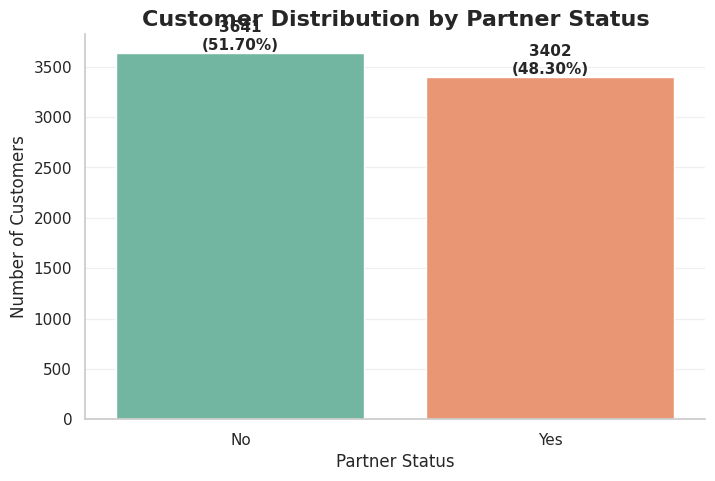

In [30]:
total = len(df)

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Partner',
    palette='Set2'
)

plt.title("Customer Distribution by Partner Status",
          fontsize=16,
          weight='bold')

plt.xlabel("Partner Status")
plt.ylabel("Number of Customers")

for p in ax.patches:

    count = int(p.get_height())
    percentage = count/total*100

    ax.annotate(f'{count}\n({percentage:.2f}%)',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

sns.despine()
plt.grid(axis='y',alpha=.3)

plt.show()

**Descriptive Insight**

The customer base includes both partnered and non-partnered individuals, providing opportunities to analyze household-related purchasing behavior.

**Diagnostic Insight**

Customers with partners may exhibit different purchasing and retention patterns because telecom services are often shared within households.

**Recommendation**

Investigate whether bundled family plans or multi-service packages improve retention among partnered customers.

Visual 8 – Top 15 Cities

Business Question

Which cities contribute the largest customer base?

/tmp/ipykernel_5677/2142931556.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


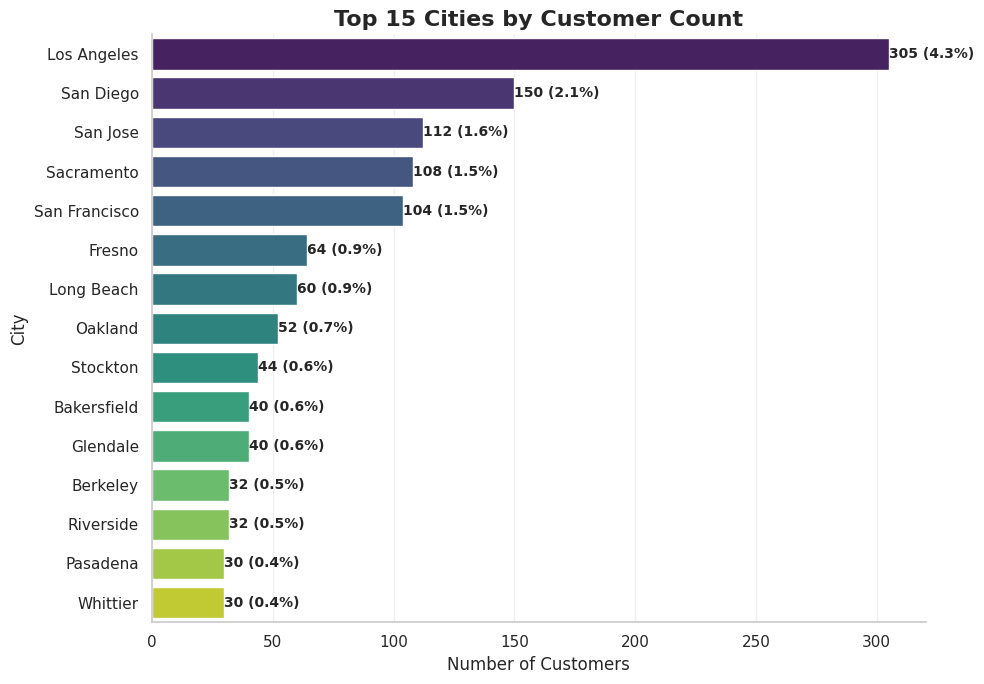

In [31]:
city = df['City'].value_counts().head(15)

plt.figure(figsize=(10,7))

ax = sns.barplot(
    x=city.values,
    y=city.index,
    palette='viridis'
)

plt.title("Top 15 Cities by Customer Count",
          fontsize=16,
          weight='bold')

plt.xlabel("Number of Customers")
plt.ylabel("City")

total = len(df)

for p in ax.patches:

    count = int(p.get_width())
    percentage = count/total*100

    ax.annotate(f'{count} ({percentage:.1f}%)',
                (count,
                 p.get_y()+p.get_height()/2),
                va='center',
                fontsize=10,
                fontweight='bold')

sns.despine()
plt.grid(axis='x',alpha=.3)

plt.tight_layout()
plt.show()

**Descriptive Insight**

Customer distribution varies across cities, with a small number of locations contributing the largest share of the customer base.

**Diagnostic Insight**

Cities with larger customer populations represent greater revenue opportunities but also pose higher financial risk if churn rates increase.

**Recommendation**

Combine customer count with churn rate and revenue metrics to identify cities where retention initiatives would have the greatest business impact.

Visual 9 – Internet Service Distribution

Business Question

Which internet service is used by most customers?

/tmp/ipykernel_5677/1097443989.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


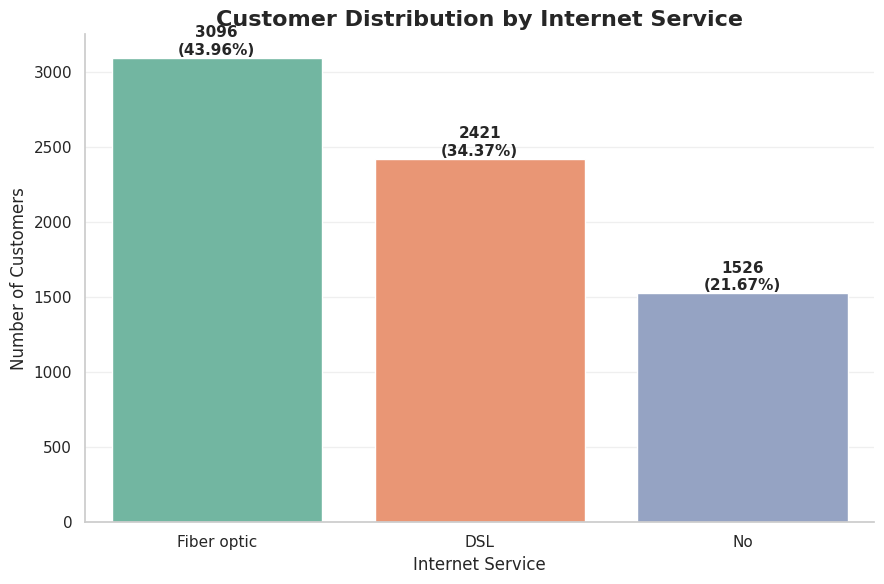

In [32]:
# ==================================
# Internet Service Distribution
# ==================================

total = len(df)

plt.figure(figsize=(9,6))

ax = sns.countplot(
    data=df,
    x='Internet Service',
    order=df['Internet Service'].value_counts().index,
    palette='Set2'
)

plt.title("Customer Distribution by Internet Service",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

for p in ax.patches:

    count = int(p.get_height())
    percentage = count/total*100

    ax.annotate(f'{count}\n({percentage:.2f}%)',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

sns.despine()
plt.grid(axis='y',alpha=.3)

plt.tight_layout()
plt.show()

**Descriptive Insight**

Most customers subscribe to DSL or Fiber Optic internet services, while a smaller proportion do not use internet services.

**Diagnostic Insight**

Internet connectivity is one of the company's core products, making it a likely driver of customer satisfaction and churn.

**Recommendation**

Compare churn across DSL and Fiber Optic customers to identify whether service quality influences retention.

Visual 10 – Phone Service

Business Question

How many customers subscribe to phone services?

/tmp/ipykernel_5677/3858653301.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


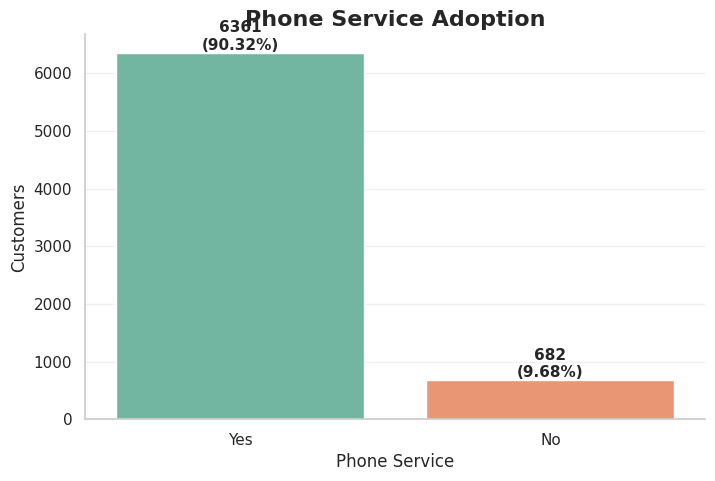

In [33]:
total = len(df)

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df,
    x='Phone Service',
    palette='Set2'
)

plt.title("Phone Service Adoption",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Phone Service")
plt.ylabel("Customers")

for p in ax.patches:

    count = int(p.get_height())
    percentage = count/total*100

    ax.annotate(f'{count}\n({percentage:.2f}%)',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                va='bottom',
                fontsize=11,
                fontweight='bold')

sns.despine()
plt.grid(axis='y',alpha=.3)

plt.show()

**Descriptive Insight**

Phone service adoption is high, indicating it remains a core offering for the majority of customers.

**Diagnostic Insight**

Customers subscribing to multiple services may have stronger engagement and potentially lower churn.

**Recommendation**

Investigate whether bundling phone and internet services improves customer retention.

Visual 11 – Multiple Lines

Business Question

How many customers have multiple phone lines?

/tmp/ipykernel_5677/1698251034.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(


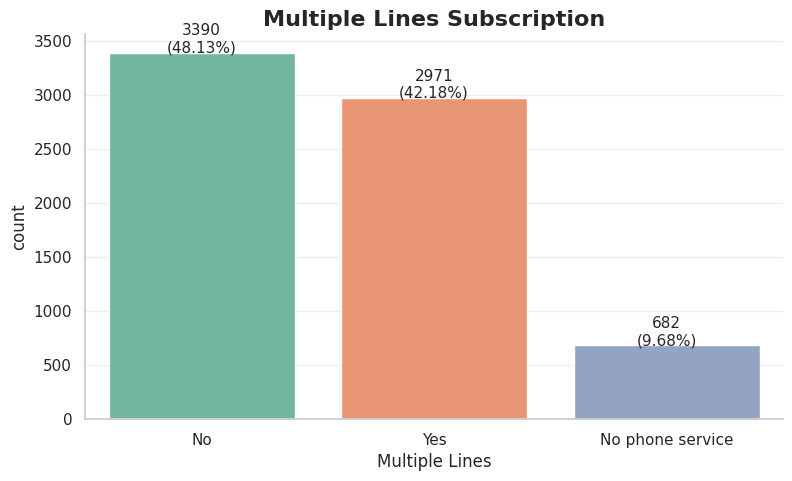

In [34]:
total=len(df)

plt.figure(figsize=(9,5))

ax=sns.countplot(
    data=df,
    x='Multiple Lines',
    order=df['Multiple Lines'].value_counts().index,
    palette='Set2'
)

plt.title("Multiple Lines Subscription",
          fontsize=16,
          weight='bold')

for p in ax.patches:

    count=int(p.get_height())
    pct=count/total*100

    ax.annotate(f'{count}\n({pct:.2f}%)',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                fontsize=11)

sns.despine()
plt.grid(axis='y',alpha=.3)

plt.show()

**Descriptive Insight**

Most customers either maintain a single phone line or do not have phone service, while a smaller group subscribes to multiple lines.

**Diagnostic Insight**

Multiple-line subscriptions may indicate family or business customers with different retention characteristics.

**Recommendation**

Compare churn rates between single-line and multiple-line customers to identify opportunities for targeted retention.

Visual 13 – Streaming Services

We'll compare Streaming TV and Streaming Movies together.

/tmp/ipykernel_5677/3845451890.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart=sns.countplot(
/tmp/ipykernel_5677/3845451890.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  chart=sns.countplot(


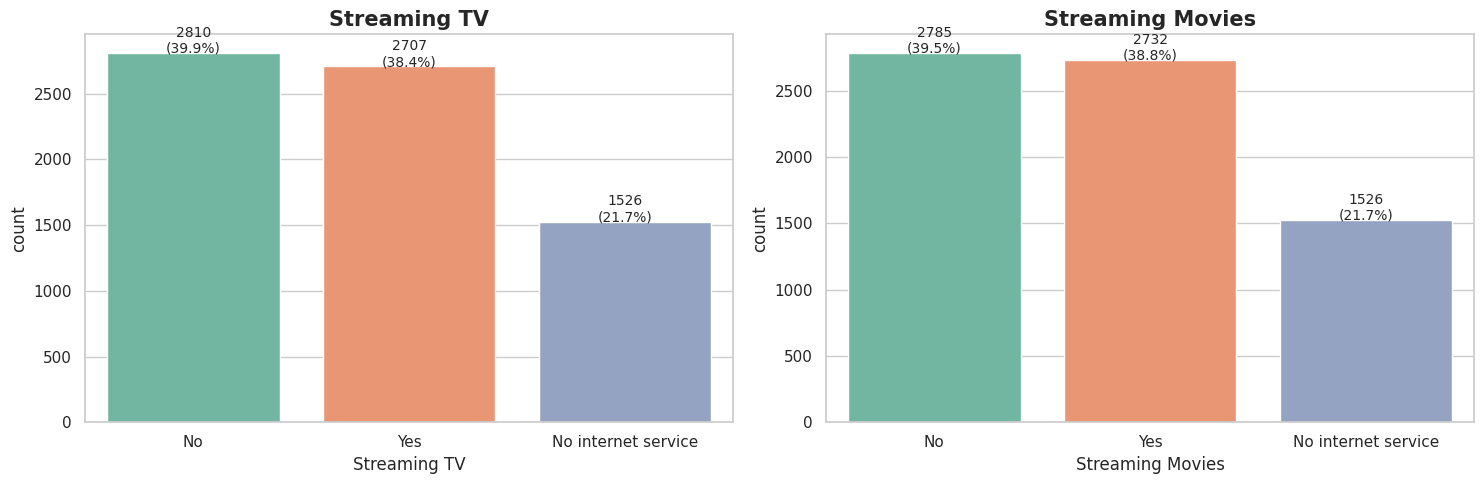

In [35]:
streaming = df[['Streaming TV','Streaming Movies']]

fig,ax = plt.subplots(1,2,figsize=(15,5))

for i,col in enumerate(streaming.columns):

    total=len(df)

    chart=sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        palette='Set2',
        ax=ax[i]
    )

    ax[i].set_title(col,
                    fontsize=15,
                    fontweight='bold')

    for p in chart.patches:

        count=int(p.get_height())
        pct=count/total*100

        chart.annotate(f'{count}\n({pct:.1f}%)',
                       (p.get_x()+p.get_width()/2,
                        p.get_height()),
                       ha='center',
                       fontsize=10)

plt.tight_layout()
plt.show()

**Descriptive Insight**

Streaming services are widely adopted, reflecting growing demand for digital entertainment.

**Diagnostic Insight**

Customers actively using streaming services may rely more heavily on broadband connectivity, making service quality an important factor in satisfaction.

**Recommendation**

Analyze whether streaming customers exhibit different churn patterns compared with non-streaming customers.

Visual 13 – Payment Method

Business Question

Which payment method is most commonly used?

/tmp/ipykernel_5677/84774300.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(


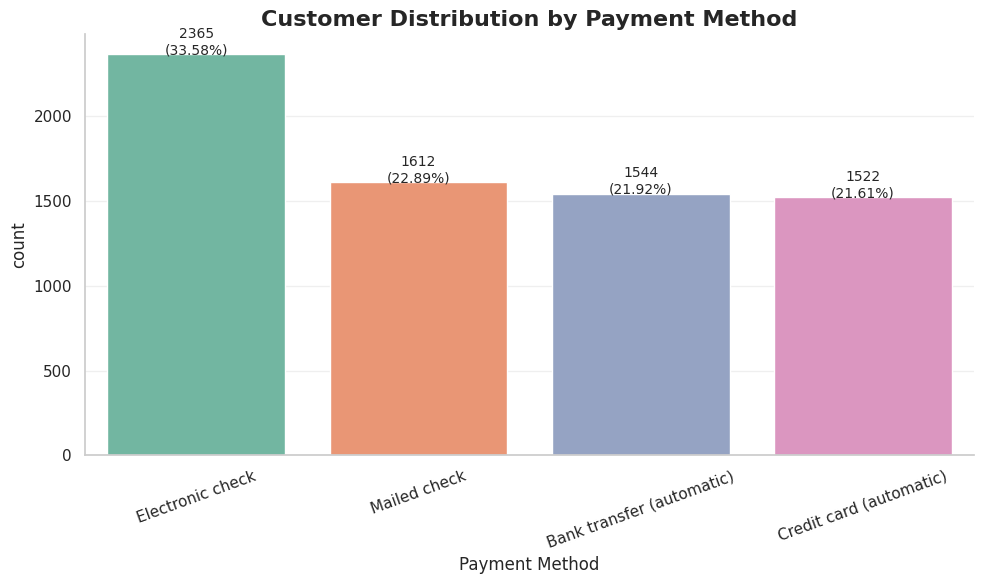

In [36]:
total=len(df)

plt.figure(figsize=(10,6))

ax=sns.countplot(
    data=df,
    x='Payment Method',
    order=df['Payment Method'].value_counts().index,
    palette='Set2'
)

plt.title("Customer Distribution by Payment Method",
          fontsize=16,
          weight='bold')

plt.xticks(rotation=20)

for p in ax.patches:

    count=int(p.get_height())
    pct=count/total*100

    ax.annotate(f'{count}\n({pct:.2f}%)',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                fontsize=10)

sns.despine()

plt.grid(axis='y',alpha=.3)

plt.tight_layout()
plt.show()

**Descriptive Insight**

Customers use a variety of payment methods, with electronic payments and automatic payment options representing a significant share.

**Diagnostic Insight**

Payment method may reflect customer convenience and loyalty. Customers using automatic payments are often less likely to miss payments or switch providers.

**Recommendation**

Analyze churn by payment method to determine whether encouraging automatic payments could improve customer retention.

Visual 16 – Churn Rate by Contract Type

Business Question

Which contract type has the highest customer churn?

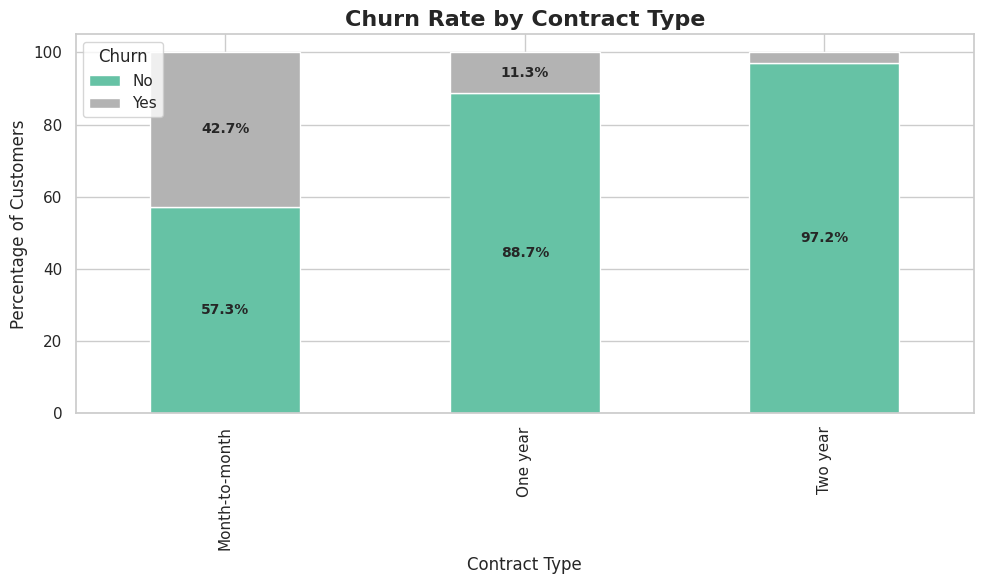

In [37]:
# ==========================================
# Churn Rate by Contract Type
# ==========================================

contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn Label'],
    normalize='index'
) * 100

contract_churn = contract_churn[['No','Yes']]

ax = contract_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='Set2'
)

plt.title("Churn Rate by Contract Type",
          fontsize=16,
          fontweight='bold')

plt.ylabel("Percentage of Customers")
plt.xlabel("Contract Type")

# Add percentage labels
for container in ax.containers:
    labels = [f"{v.get_height():.1f}%" if v.get_height() > 5 else "" for v in container]
    ax.bar_label(container, labels=labels, label_type='center',
                 fontsize=10, fontweight='bold')

plt.legend(title="Churn")
plt.tight_layout()
plt.show()

**Descriptive Insight**

Month-to-month contracts have the highest churn percentage, while one-year and two-year contracts show much higher customer retention.

**Diagnostic Insight**

Customers without long-term commitments can change providers more easily. Longer contracts create greater customer stickiness.

**Recommendation**

Offer discounts, loyalty rewards, or bundled services to encourage month-to-month customers to migrate to annual contracts.

Visual 17 – Internet Service vs Churn

Business Question

Does churn vary by internet service?

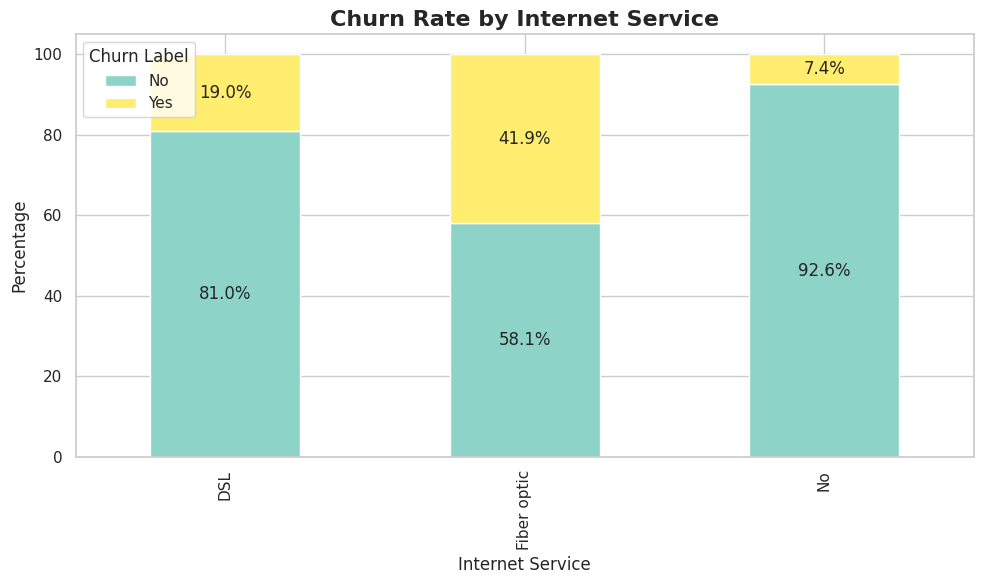

In [38]:
internet_churn = pd.crosstab(
    df['Internet Service'],
    df['Churn Label'],
    normalize='index'
) * 100

internet_churn = internet_churn[['No','Yes']]

ax = internet_churn.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='Set3'
)

plt.title("Churn Rate by Internet Service",
          fontsize=16,
          fontweight='bold')

plt.ylabel("Percentage")

for container in ax.containers:
    labels = [f"{v.get_height():.1f}%" if v.get_height() > 5 else "" for v in container]
    ax.bar_label(container, labels=labels, label_type='center')

plt.tight_layout()
plt.show()

**Recommendation**

From the chart it shows fiber Optic customers experience higher churn because of pricing, service quality, or customer expectations.

Visual 18 – Monthly Charges vs Churn

Business Question

Are customers paying higher monthly charges more likely to churn?

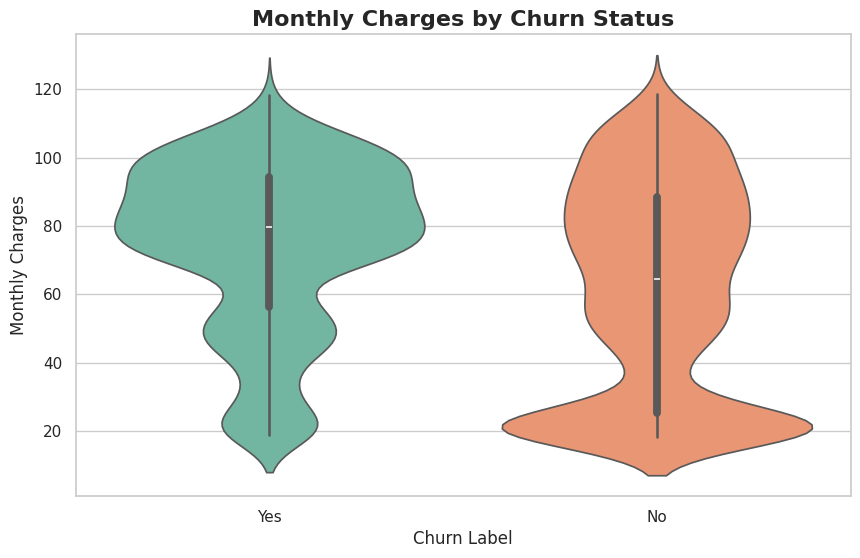

In [42]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='Churn Label',
    y='Monthly Charges',
    hue='Churn Label', # Added hue argument as recommended by the warning
    palette='Set2',
    legend=False # Set legend to False to avoid redundant legend
)

plt.title("Monthly Charges by Churn Status",
          fontsize=16,
          fontweight='bold')

plt.show()

**Recommendation**

If churned customers tend to have higher monthly charges, consider reviewing pricing, bundling, or promotional offers for high-value customers.

Visual 19 – Tenure vs Churn

Business Question

Do newer customers churn more frequently?

/tmp/ipykernel_5677/3694791323.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


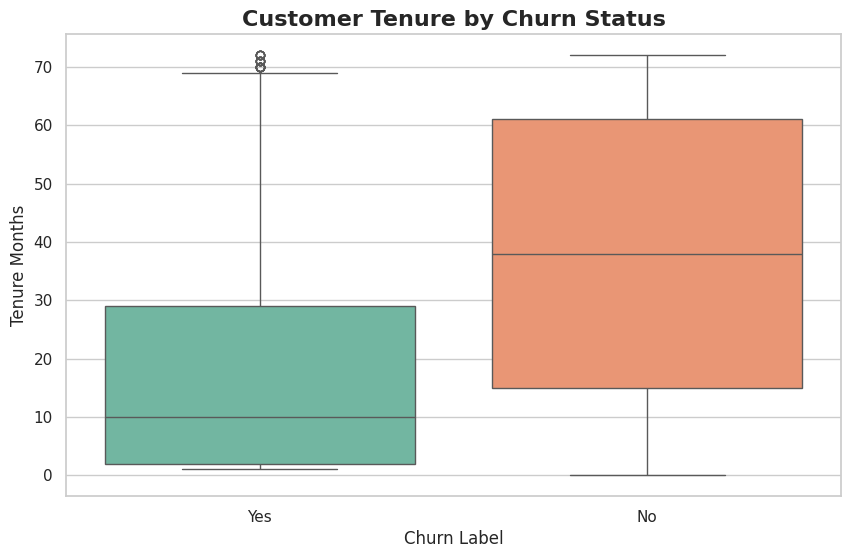

In [44]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x='Churn Label',
    y='Tenure Months',
    hue='Churn Label', # Added hue argument as recommended by the warning
    palette='Set2',
    legend=False # Set legend to False to avoid redundant legend
)

plt.title("Customer Tenure by Churn Status",
          fontsize=16,
          fontweight='bold')

plt.show()

**Recommendation**

Strengthen onboarding and engagement during the first year, when customers are most vulnerable to leaving.

Visual 20 – Payment Method vs Churn

Business Question

Which payment methods are associated with the highest churn?

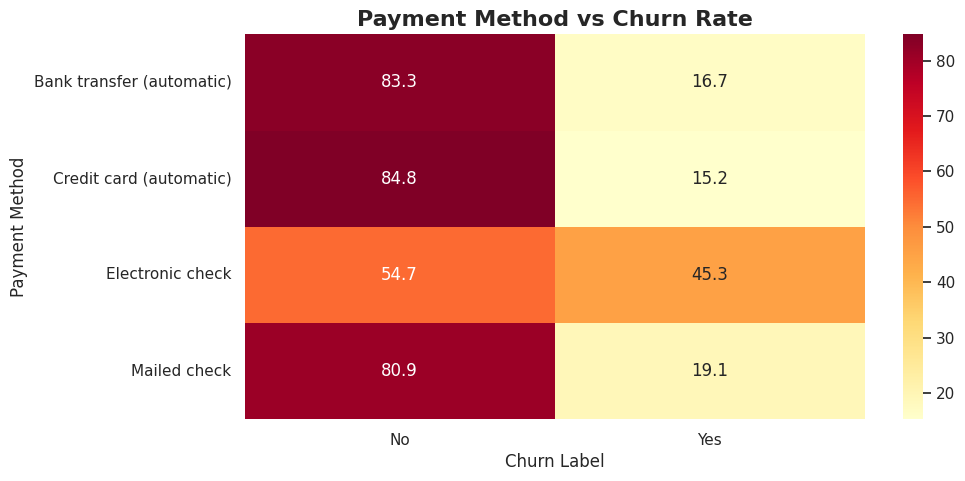

In [45]:
payment = pd.crosstab(
    df['Payment Method'],
    df['Churn Label'],
    normalize='index'
) * 100

plt.figure(figsize=(10,5))

sns.heatmap(
    payment,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("Payment Method vs Churn Rate",
          fontsize=16,
          fontweight='bold')

plt.show()

**Recommendation**

Promote automatic payment options if they are associated with better retention.

Visual 21 – Top Churn Reasons

Business Question

Why are customers leaving?

/tmp/ipykernel_5677/297245497.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


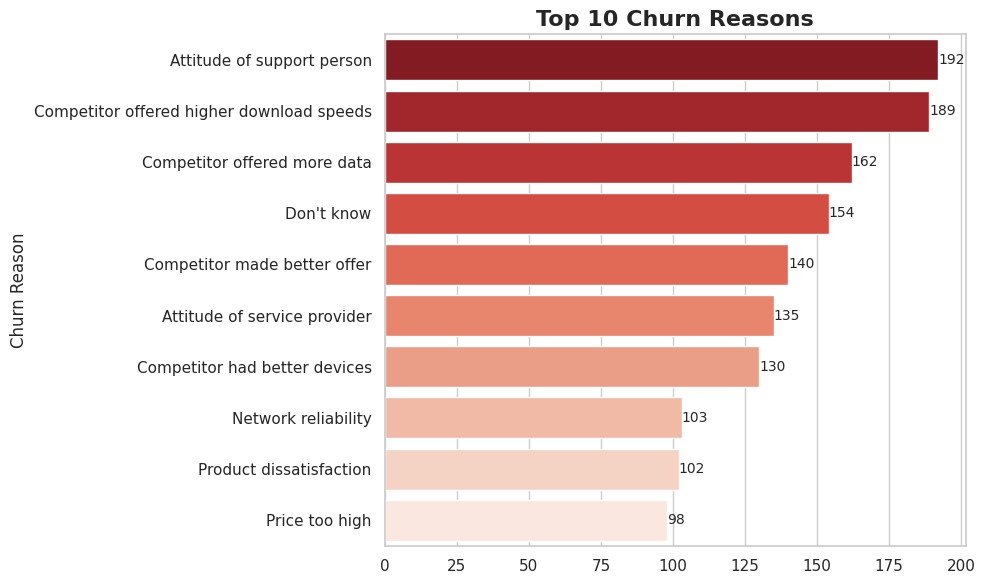

In [46]:
churn_reason = (
    df[df['Churn Label']=='Yes']
    ['Churn Reason']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=churn_reason.values,
    y=churn_reason.index,
    palette='Reds_r'
)

plt.title("Top 10 Churn Reasons",
          fontsize=16,
          fontweight='bold')

for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",
                (p.get_width(), p.get_y()+p.get_height()/2),
                va='center',
                fontsize=10)

plt.tight_layout()
plt.show()

**Recommendation**

Group churn reasons into categories (Price, Competitor, Service Quality, Support, Product) to guide targeted improvement initiatives.

Visual 22 – Churn Score Distribution

Business Question

How are customers distributed by churn risk?

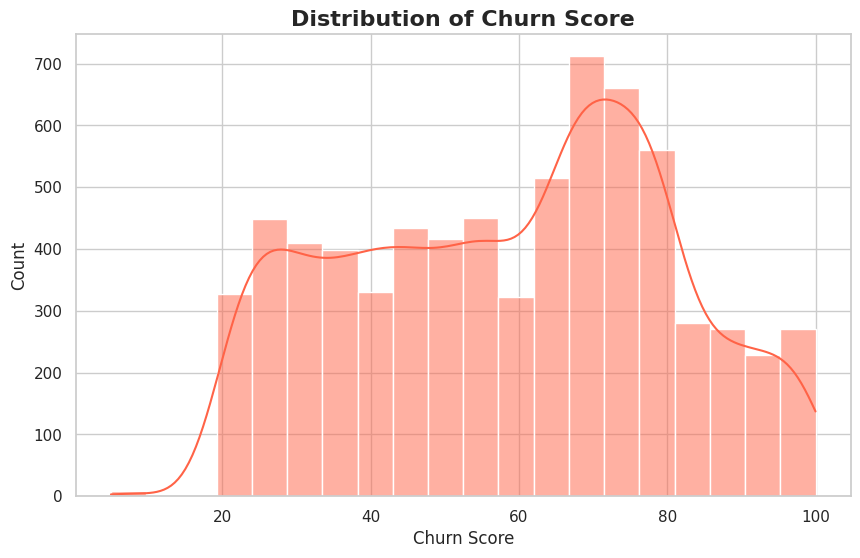

In [47]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='Churn Score',
    bins=20,
    kde=True,
    color='tomato'
)

plt.title("Distribution of Churn Score",
          fontsize=16,
          fontweight='bold')

plt.show()

**Recommendation**

Define risk bands (Low, Medium, High) to prioritize retention campaigns.

Visual 23 – Customer Risk Matrix

Business Question

Does the churn score effectively identify customers at risk?

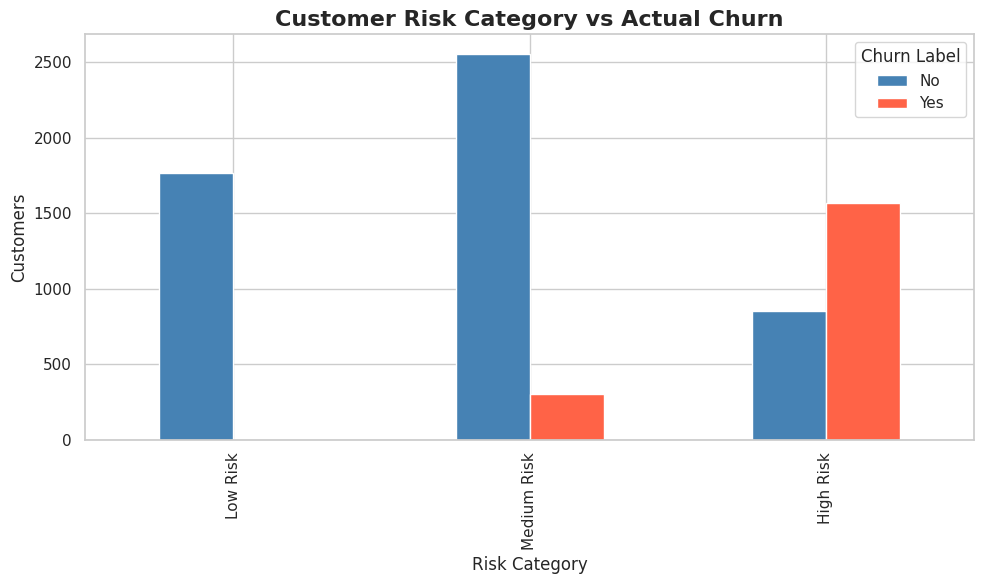

In [48]:
df['Risk Category'] = pd.cut(
    df['Churn Score'],
    bins=[0,40,70,100],
    labels=['Low Risk','Medium Risk','High Risk']
)

risk = pd.crosstab(
    df['Risk Category'],
    df['Churn Label']
)

ax = risk.plot(
    kind='bar',
    figsize=(10,6),
    color=['steelblue','tomato']
)

plt.title("Customer Risk Category vs Actual Churn",
          fontsize=16,
          fontweight='bold')

plt.ylabel("Customers")
plt.xlabel("Risk Category")

plt.tight_layout()
plt.show()

**Recommendation**

Use the High Risk segment to drive proactive retention campaigns and monitor model performance over time.

**Executive Summary – Churn Analysis**

**Key Findings**

Month-to-month customers have the highest churn rates.
Customer tenure is strongly associated with retention.
Customers with higher monthly charges appear more likely to churn.
Churn varies across internet service and payment methods.
Competitor offers, pricing, and service experience are the most common reasons for leaving.
Churn scores can be used to prioritize proactive retention efforts.

**Recommended Business Actions**

Convert month-to-month customers to annual contracts.
Strengthen customer onboarding during the first year.
Review pricing and value propositions for high-charge customers.
Improve customer support and service quality where relevant.
Focus retention campaigns on customers with high churn scores.

**Calculate KPI Metrics**

In [50]:
# ==============================
# Executive KPIs
# ==============================

total_customers = len(df)

active_customers = (df['Churn Label'] == 'No').sum()

churned_customers = (df['Churn Label'] == 'Yes').sum()

churn_rate = (churned_customers / total_customers) * 100

total_revenue = df['Total Charges'].sum() # Corrected column name to 'Total Charges'

avg_cltv = df['CLTV'].mean()

avg_tenure = df['Tenure Months'].mean()

print(f"Total Customers : {total_customers:,}")
print(f"Active Customers : {active_customers:,}")
print(f"Churned Customers : {churned_customers:,}")
print(f"Churn Rate : {churn_rate:.2f}%")
print(f"Total Revenue : ${total_revenue:,.0f}")
print(f"Average CLTV : ${avg_cltv:,.0f}")
print(f"Average Tenure : {avg_tenure:.1f} months")

Total Customers : 7,043
Active Customers : 5,174
Churned Customers : 1,869
Churn Rate : 26.54%
Total Revenue : $16,056,169
Average CLTV : $4,400
Average Tenure : 32.4 months


**Executive KPI Cards**

In [55]:
from IPython.display import HTML

HTML(f"""

<h1 style='text-align:center;
color:#2E4053;'>
Customer Churn Analytics &
Retention Intelligence Platform
</h1>

<hr>

<table style="width:100%;">

<tr>

<td style="background:#2E86C1;
color:white;
padding:15px;
border-radius:10px;
text-align:center;">

<h3>Total Customers</h3>

<h1>{total_customers:,}</h1>

</td>

<td style="background:#E74C3C;
color:white;
padding:15px;
text-align:center;">

<h3>Churn Rate</h3>

<h1>{churn_rate:.2f}%</h1>

</td>

<td style="background:#27AE60;
color:white;
padding:15px;
text-align:center;">

<h3>Total Revenue</h3>

<h1>${total_revenue:,.0f}</h1>

</td>

<td style="background:#8E44AD;
color:white;
padding:15px;
text-align:center;">

<h3>Avg CLTV</h3>

<h1>${avg_cltv:,.0f}</h1>

</td>

<td style="background:#F39C12;
color:white;
padding:15px;
text-align:center;">

<h3>Avg Tenure</h3>

<h1>{avg_tenure:.1f}</h1>

</td>

</tr>

</table>

""")

"Total Customers 7,043",Churn Rate 26.54%,"Total Revenue $16,056,169","Avg CLTV $4,400",Avg Tenure 32.4


**Top Five Findings**


**Executive Findings**

**1. Customer Churn**

Approximately 26.5% of customers have churned, indicating a substantial opportunity to improve retention.

**2. Contract Type**

Customers on Month-to-Month contracts exhibit the highest churn rates, while long-term contracts retain customers more effectively.

**3. Customer Tenure**

Customers with shorter tenures are significantly more likely to churn, highlighting the importance of the onboarding period.

**4. Revenue Risk**

High-value customers contribute a significant share of revenue, making churn among these customers particularly costly.

**5. Churn Drivers**

The most common reasons for churn relate to competitor offers, pricing, and service quality, suggesting opportunities to strengthen the company's value proposition.

**Three Strategic Recommendations**

**Recommendation 1**  

Improve Early Customer Retention

Focus retention efforts on customers within their first 12 months through welcome campaigns, onboarding support, and proactive engagement.

**Recommendation 2 **

Promote Long-Term Contracts

Encourage month-to-month customers to migrate to annual contracts by offering discounts, loyalty rewards, or bundled services.

**Recommendation 3**

Prioritize High-Value Customers

Use CLTV and Churn Score to identify customers whose departure would have the greatest financial impact and target them with personalized retention offers.

# Transition to Power BI

The Python analysis established the key business insights, identified customer segments, and prepared a clean dataset.

The next phase of the project focuses on developing an interactive Power BI dashboard for executive decision-making.

The dashboard will include:

- Executive KPI Overview
- Customer Demographics
- Customer Behaviour
- Churn Analysis
- Revenue & CLTV
- Customer Segmentation
- Strategic Recommendations